# SOCAT co-location to Argo floats

In [1]:
# os tools
import sys
import os
import os.path
import requests
import time
import urllib3
import shutil
from tqdm import tqdm

# data tools
import numpy                 as np
import pandas                as pd
import xarray                as xr
from   datetime              import date, datetime, timedelta                 # for saving figures with today's date
import datetime
import scipy
from   scipy.stats           import kruskal              # for boxenplot stats
from   scipy.stats           import mannwhitneyu         # for split violin plot stats
import gsw


# for all plots
import matplotlib
import matplotlib.pyplot     as plt                      # needed to make map setup
import matplotlib.colors     as colors
from   matplotlib.ticker     import EngFormatter         # for degree symbol in axis
from   cmocean               import cm as cmo
import seaborn               as     sns

# for map
import shapefile
import cartopy                                           # to make map
import matplotlib.path       as     mpath                # to draw circle for map
import cartopy.crs           as     ccrs                 # for map projection
import cartopy.feature       as     cfeature             # to add land features to map
# from   xhistogram.xarray     import histogram            # for map histogram
# from   mycolorpy             import colorlist as mcp     # to get n colors list
import pyproj  
import geopandas             as     gpd                  # for adding shapefiles of frontal zones 
from   osgeo                 import gdal
# import scikit_posthocs       as     sp                   # for stats

In [2]:
# Custom modules
import mod_cremas as crx 
import mod_ocean as myocn


from importlib import reload
import mod_plotting as myplt
# from mod_plotting import setup_SO_axes

plt.rcParams.update(myplt.my_params(size=12))

In [3]:
import shapefile
so_fronts = shapefile.Reader('./shapefiles/fronts/so_fronts.shp') 
stf_mod   = shapefile.Reader('./shapefiles/fronts/stf_mod/stf_mod.shp')

stf  = stf_mod.shape(0).points
saf  = so_fronts.shape(1).points
pf   = so_fronts.shape(2).points
sacc = so_fronts.shape(3).points
sie  = so_fronts.shape(4).points

max_latitude:          float = -30
add_gridlines:         bool  = True
color_land:            bool  = False
land_edgecolor:        str   = 'grey'
land_facecolor:        str   = 'grey'
fontsize:              float = 10
map_facecolor:         str   = 'white'
coast_linewidth:       float = 0.3
gridlines_linewidth:   float = 0.5
girdlines_color:       str   = 'grey'
gridlines_alpha:       float = 0.5
longitude_label_color: str   = 'grey'
latitude_label_color:  str   = 'grey'

In [4]:
datetag = '20250218'
coreDS = xr.open_dataset('../working-vars/argo/coreDS_qc_interp_2014-2023_acc' + datetag + '.nc')
core_INDEX = xr.open_dataset('../working-vars/argo/core_INDEX_qc_interp_2014-2023_acc' + datetag + '.nc')

/opt/homebrew/Caskroom/mambaforge/base/envs/cremas/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


In [ ]:
# coreDS = xr.open_dataset('/Users/sangminsong/Library/CloudStorage/OneDrive-UW/Code/CREMAS/data/coreDS_jan2014_20250204.nc')

# coreDS_ave = coreDS.reset_coords().mean(dim='pressure')

/opt/homebrew/Caskroom/mambaforge/base/envs/cremas/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


In [5]:
socat_3h = pd.read_csv('../data/SOCATv2024_SO_resampled_3h_median_2025Jan21.csv')
socat_3h['yearday'] = myocn.datetime2ytd(socat_3h['datetime'].astype('datetime64[ns]'), ref_time='2014-01-01')

In [6]:
socat_3h

,longitude,latitude,fco2rec,sal,sst,datetime,expoID,yearday
0,-22.258930,-30.118180,392.8250,35.9020,20.3330,2020-11-25 15:00:00,69920201125_id0,2520.625
1,-22.398631,-30.475685,390.7465,35.8650,20.0705,2020-11-25 18:00:00,69920201125_id0,2520.750
2,-22.472252,-31.011730,391.4340,35.7110,19.0240,2020-11-25 21:00:00,69920201125_id0,2520.875
3,-22.533344,-31.691980,388.6850,35.6690,18.9380,2020-11-26 00:00:00,69920201125_id0,2521.000
4,-22.699829,-32.343170,389.1875,35.5935,18.4280,2020-11-26 03:00:00,69920201125_id0,2521.125
...,...,...,...,...,...,...,...,...
110597,168.511617,-33.497930,362.9700,35.4465,17.2905,2023-10-26 06:00:00,PAT520231025_id0,3585.250
110598,167.899881,-32.686910,370.1930,35.5380,17.9885,2023-10-26 09:00:00,PAT520231025_id0,3585.375
110599,167.153976,-31.659615,365.9290,35.6945,19.3550,2023-10-26 12:00:00,PAT520231025_id0,3585.500
110600,166.757876,-31.057040,367.1620,35.7400,19.9025,2023-10-26 15:00:00,PAT520231025_id0,3585.625


In [ ]:

def alongtrack_fsle(diveav,FSLE):
    """ 
    Nearest neighbor interpolation to daily FSLE values along glider path 
    @param <FSLE>      satellite FSLE over deployment period """
    dates = diveav.date
    track_fsle = np.array([])       # initialize array to return
   
    for idx, date in enumerate(dates):               
        glider_lat = diveav.latitude[idx]
        glider_lon = diveav.longitude[idx]
        temp_fsle = FSLE.sel(time=date, lat=glider_lat, lon=glider_lon,
                             method = 'nearest')
        
        track_fsle = np.append(track_fsle, temp_fsle.fsle_max.values)
    return track_fsle

## First try

In [124]:
# def add_colocation(platDF, argoDS, ref_time='2014-01-01') -> pd.DataFrame:
#     """  
#     Find nearest argo profile to each SOCAT observation, calculate distance and yearday separation
#     @param    platDF: DataFrame of SOCAT observations with latitude, longitude
#               argoDS: xr Dataset with "pressure", "profid" coordinates

#     """

#     colocation = pd.DataFrame(index=platDF.index, columns=
#                                 ['nearest_profid', 'prof_datetime', 'prof_lat', 'prof_lon',
#                                  'yd_sep', 'ydcos_sep', 'ydsin_sep', 'km_sep'])

#     # Make sure dataframes have the seasonal variables
#     argoDF = argoDS.reset_coords().mean(dim='pressure').to_dataframe()
#     argoDF['datetime'] = myocn.ytd2datetime(argoDF['yearday'], ref_time=ref_time)
#     [argoDF['ydcos'], argoDF['ydsin']] = myocn.get_ydsines(argoDF.yearday.values)
    
#     platDF['yearday'] = myocn.datetime2ytd(platDF['datetime'].astype('datetime64[ns]'), ref_time=ref_time)
#     [platDF['ydcos'], platDF['ydsin']] = myocn.get_ydsines(platDF.yearday.values)

#     for idx, row in platDF.iterrows():
#         # Recalculate distance and yearday separation for each socat obs
#         argoDF['yd_sep'] = argoDF.yearday.map(lambda x: abs(x - row['yearday']))
#         argoDF['ydcos_sep'] = argoDF.ydcos.map(lambda x: abs(x - row['ydcos']))
#         argoDF['ydsin_sep'] = argoDF.ydsin.map(lambda x: abs(x - row['ydsin']))
#         argoDF['km_sep'] = argoDF.apply(lambda x: gsw.distance([row['longitude'], x.longitude], 
#                                                                 [row['latitude'], x.latitude]), axis=1) # m
        
#         # Find minimum dist separation
#         imin = argoDF.idxmin().km_sep
#         colocation.loc[idx, 'nearest_profid'] = imin
#         colocation.loc[idx, 'prof_datetime'] = argoDF.loc[imin].datetime
#         colocation.loc[idx, 'prof_lat'] = argoDF.loc[imin].latitude
#         colocation.loc[idx, 'prof_lon'] = argoDF.loc[imin].longitude
#         colocation.loc[idx, 'yd_sep'] = argoDF.loc[imin].yd_sep%365
#         colocation.loc[idx, 'ydcos_sep'] = argoDF.loc[imin].ydcos_sep
#         colocation.loc[idx, 'ydsin_sep'] = argoDF.loc[imin].ydsin_sep
#         colocation.loc[idx, 'km_sep'] = argoDF.loc[imin].km_sep/1000 # km


#     return pd.concat([platDF, colocation], axis=1)

In [142]:
# Setup example data to make colocation function
platDF = myocn.expand_datetime(socat_3h.iloc[:200])
# platDF['yearday'] = myocn.datetime2ytd(platDF['datetime'].astype('datetime64[ns]'), ref_time='2014-01-01')
[platDF['ydcos'], platDF['ydsin']] = myocn.get_ydsines(platDF.yearday.values)

argoDF = coreDS.reset_coords().mean(dim='pressure').to_dataframe()
[argoDF['ydcos'], argoDF['ydsin']] = myocn.get_ydsines(argoDF.yearday.values)


/Users/sangminsong/Library/CloudStorage/OneDrive-UW/Code/CREMAS/src/mod_ocean.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ydsin = np.sin(2*np.pi*np.array(yearday)/365)
/Users/sangminsong/Library/CloudStorage/OneDrive-UW/Code/CREMAS/src/mod_ocean.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/Users/sangminsong/Library/CloudStorage/OneDrive-UW/Code/CREMAS/src/mod_ocean.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer

In [168]:
temp.where(temp.month.isin([6, 8]), drop=True).to_dataframe()

<xarray.Dataset>
Dimensions:      (profid: 1822, pressure: 500)
Coordinates:
  * profid       (profid) object '1900410_id275' ... '7900652_id011'
  * pressure     (pressure) int64 2 4 6 8 10 12 14 ... 990 992 994 996 998 1000
    yearday      (profid, pressure) float64 nan nan nan ... 170.4 170.4 170.4
    latitude     (profid, pressure) float64 nan nan nan ... -61.37 -61.37 -61.37
    longitude    (profid, pressure) float64 nan nan nan ... 109.5 109.5 109.5
    wmoid        (profid, pressure) float64 nan nan nan ... 7.901e+06 7.901e+06
    datetime     (profid, pressure) datetime64[ns] 2014-06-03T14:37:35 ... 20...
    year         (profid, pressure) int64 2014 2014 2014 2014 ... 2014 2014 2014
    month        (profid, pressure) int64 6 6 6 6 6 6 6 6 6 ... 6 6 6 6 6 6 6 6
    day          (profid, pressure) int64 3 3 3 3 3 3 3 ... 20 20 20 20 20 20 20
Data variables:
    CT           (profid, pressure) float64 nan nan nan ... 1.421 1.42 1.419
    SA           (profid, pressure) float64 nan nan nan ... 34.91 34.9 34.9
    sigma0       (profid, pressure) float64 nan nan nan ... 27.81 27.81 27.81
    spice        (profid, pressure) float64 nan nan nan ... -0.07991 -0.08018
    temperature  (profid, pressure) float64 nan nan nan ... 1.478 1.476 1.475
    salinity     (profid, pressure) float64 nan nan nan ... 34.73 34.73 34.73
Attributes:
    title:    Jan 2014 Core floats, interpolated to regular pressure grid [0,...
    source:   Argopy, research mode
    date:     2025-02-04 15:46:02.200138

In [224]:
# Trying something different, where you slice argoDS to just the same month as the SOCAT data
reload(mod_argo)
mod_argo.colocate_to_floats

# Moved to mod_Argo
# def colocate_to_floats(platDF, argoDS, ref_time = '2014-01-01') -> pd.DataFrame:
#     """  
#     Find nearest argo profile to each SOCAT observation, calculate distance and yearday separation
#     @param    platDF: DataFrame of SOCAT observations with latitude, longitude
#               argoDS: xr Dataset with "pressure", "profid" coordinates

#     """

#     argoDS = myocn.expand_datetime(argoDS, type='dataset') # adds month as coordinate
#     platDF = myocn.expand_datetime(platDF, type='dataframe')

#     colocation = pd.DataFrame(index=platDF.index, columns=
#                                 ['nearest_profid', 'prof_datetime', 'prof_lat', 'prof_lon',
#                                   'km_sep', 'yd_sep'])

#     molist = [12, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 1]

#     for idx in tqdm(platDF.index):
#         # For each socat obs, subset Argo data to same month +/- 1 month
#         row = platDF.loc[idx]
#         valid_months = molist[row['month']-1:row['month']+2]
#         argoset = argoDS.where(argoDS.month.isin(valid_months), drop=True)
#         argoDF = argoset.reset_coords().mean(dim='pressure').to_dataframe()
        
#         if len(argoDF) > 0:
#             # Recalculate distance and yearday separation for each socat obs
#             argoDF['yd_sep'] = argoDF.yearday.map(lambda x: abs(x - row['yearday'])%365)  # note mod 365 
#             argoDF['km_sep'] = argoDF.apply(lambda x: gsw.distance([row['longitude'], x.longitude], 
#                                                                     [row['latitude'], x.latitude]), axis=1) # m
#             # Find minimum dist separation
#             imin = argoDF.idxmin().km_sep
#             colocation.loc[idx, 'nearest_profid'] = imin
#             colocation.loc[idx, 'prof_datetime'] = myocn.ytd2datetime(argoDF.loc[imin].yearday, ref_time=ref_time)
#             colocation.loc[idx, 'prof_lat'] = argoDF.loc[imin].latitude
#             colocation.loc[idx, 'prof_lon'] = argoDF.loc[imin].longitude
#             colocation.loc[idx, 'yd_sep'] = argoDF.loc[imin].yd_sep
#             colocation.loc[idx, 'km_sep'] = argoDF.loc[imin].km_sep/1000

#     return pd.concat([platDF, colocation], axis=1)

In [198]:
argoDS = myocn.expand_datetime(coreDS, type='dataset') # adds month as coordinate
platDF = myocn.expand_datetime(socat_3h, type='dataframe')

colocation = pd.DataFrame(index=platDF.index, columns=
                            ['nearest_profid', 'prof_datetime', 'prof_lat', 'prof_lon',
                                'yd_sep', 'km_sep'])
argoDF = argoset.reset_coords().mean(dim='pressure').to_dataframe()
molist = [12, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 1]

for idx, row in platDF.iterrows():
    # For each socat obs, subset Argo data to same month +/- 1 month
    valid_months = molist[row['month']-1:row['month']+2]
    argoset = argoDS.where(argoDS.month.isin(valid_months), drop=True)
    
    
    # Recalculate distance and yearday separation for each socat obs
    argoDF['yd_sep'] = argoDF.yearday.map(lambda x: abs(x - row['yearday']))
    argoDF['km_sep'] = argoDF.apply(lambda x: gsw.distance([row['longitude'], x.longitude], 
                                                            [row['latitude'], x.latitude]), axis=1) # m
    # Find minimum dist separation
    if len:
        imin = argoDF.idxmin().km_sep
        colocation.loc[idx, 'nearest_profid'] = imin
        colocation.loc[idx, 'prof_datetime'] = argoDF.loc[imin].datetime
        colocation.loc[idx, 'prof_lat'] = argoDF.loc[imin].latitude
        colocation.loc[idx, 'prof_lon'] = argoDF.loc[imin].longitude
        colocation.loc[idx, 'yd_sep'] = argoDF.loc[imin].yd_sep%365
        colocation.loc[idx, 'km_sep'] = argoDF.loc[imin].km_sep/1000

ValueError: attempt to get argmin of an empty sequence

# MAIN COLOCATION FUNCTION 

In [7]:
import mod_argo

result = mod_argo.colocate_to_floats(socat_3h.iloc[0:1000], coreDS)

/opt/homebrew/Caskroom/mambaforge/base/envs/cremas/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
  0%|          | 0/1000 [00:00<?, ?it/s]/opt/homebrew/Caskroom/mambaforge/base/envs/cremas/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/opt/homebrew/Caskroom/mambaforge/base/envs/cremas/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
  0%|          | 1/1000 [00:39<10:51:37, 39.14s/it]/opt/homebrew/Caskroom/mambaforge/base/envs/cremas/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * 

KeyboardInterrupt: 

In [ ]:
result

,longitude,latitude,fco2rec,sal,sst,datetime,expoID,yearday,year,month,day,nearest_profid,prof_datetime,prof_lat,prof_lon,km_sep,yd_sep
3505,-55.674982,-37.261400,359.2510,33.3340,14.0390,2023-06-01 00:00:00,08D820230521_id2,3438.000,2023,6,1,1901626_id064,2014-06-26,-38.78955,-53.12426,280.67827897298133,341.61272
3506,-55.557723,-37.337600,363.2175,33.3305,13.9655,2023-06-01 03:00:00,08D820230521_id2,3438.125,2023,6,1,1901626_id064,2014-06-26,-38.78955,-53.12426,267.288770588,341.73772
3507,-55.398865,-37.415600,342.3490,33.3240,13.2020,2023-06-01 06:00:00,08D820230521_id2,3438.250,2023,6,1,1901626_id064,2014-06-26,-38.78955,-53.12426,250.8892446540743,341.86272
3508,-55.482335,-37.397400,351.1815,33.3230,13.5885,2023-06-01 09:00:00,08D820230521_id2,3438.375,2023,6,1,1901626_id064,2014-06-26,-38.78955,-53.12426,257.95004151342397,341.98772
3509,-55.622173,-37.265600,379.3400,33.3400,14.0800,2023-06-01 12:00:00,08D820230521_id2,3438.500,2023,6,1,1901626_id064,2014-06-26,-38.78955,-53.12426,276.72035689872456,342.11272
3510,-55.983983,-37.458250,386.7995,33.5160,14.4150,2023-06-01 15:00:00,08D820230521_id3,3438.625,2023,6,1,1901626_id064,2014-06-26,-38.78955,-53.12426,290.6502603527015,342.23772
3511,-55.782240,-37.661900,346.6710,33.4800,13.0210,2023-06-01 18:00:00,08D820230521_id3,3438.750,2023,6,1,1901626_id064,2014-06-26,-38.78955,-53.12426,263.85924908987784,342.36272
3512,-55.950464,-37.844300,325.9840,33.4930,12.9480,2023-06-01 21:00:00,08D820230521_id3,3438.875,2023,6,1,1901626_id064,2014-06-26,-38.78955,-53.12426,268.0177579714633,342.48772
3513,-56.002760,-37.957900,341.5290,33.4710,13.4370,2023-06-02 00:00:00,08D820230521_id3,3439.000,2023,6,2,1901626_id064,2014-06-26,-38.78955,-53.12426,267.41352502706616,342.61272
3514,-55.706029,-38.161650,331.7965,33.3575,11.9610,2023-06-02 03:00:00,08D820230521_id3,3439.125,2023,6,2,1901626_id064,2014-06-26,-38.78955,-53.12426,235.332024889638,342.73772


In [ ]:
result

,longitude,latitude,fco2rec,sal,sst,datetime,expoID,yearday,year,month,day,nearest_profid,prof_datetime,prof_lat,prof_lon,km_sep,yd_sep
3505,-55.674982,-37.261400,359.2510,33.3340,14.0390,2023-06-01 00:00:00,08D820230521_id2,3438.000,2023,6,1,1901626_id064,2014-06-26,-38.78955,-53.12426,280.67827897298133,341.61272
3506,-55.557723,-37.337600,363.2175,33.3305,13.9655,2023-06-01 03:00:00,08D820230521_id2,3438.125,2023,6,1,1901626_id064,2014-06-26,-38.78955,-53.12426,267.288770588,341.73772
3507,-55.398865,-37.415600,342.3490,33.3240,13.2020,2023-06-01 06:00:00,08D820230521_id2,3438.250,2023,6,1,1901626_id064,2014-06-26,-38.78955,-53.12426,250.8892446540743,341.86272
3508,-55.482335,-37.397400,351.1815,33.3230,13.5885,2023-06-01 09:00:00,08D820230521_id2,3438.375,2023,6,1,1901626_id064,2014-06-26,-38.78955,-53.12426,257.95004151342397,341.98772
3509,-55.622173,-37.265600,379.3400,33.3400,14.0800,2023-06-01 12:00:00,08D820230521_id2,3438.500,2023,6,1,1901626_id064,2014-06-26,-38.78955,-53.12426,276.72035689872456,342.11272
3510,-55.983983,-37.458250,386.7995,33.5160,14.4150,2023-06-01 15:00:00,08D820230521_id3,3438.625,2023,6,1,1901626_id064,2014-06-26,-38.78955,-53.12426,290.6502603527015,342.23772
3511,-55.782240,-37.661900,346.6710,33.4800,13.0210,2023-06-01 18:00:00,08D820230521_id3,3438.750,2023,6,1,1901626_id064,2014-06-26,-38.78955,-53.12426,263.85924908987784,342.36272
3512,-55.950464,-37.844300,325.9840,33.4930,12.9480,2023-06-01 21:00:00,08D820230521_id3,3438.875,2023,6,1,1901626_id064,2014-06-26,-38.78955,-53.12426,268.0177579714633,342.48772
3513,-56.002760,-37.957900,341.5290,33.4710,13.4370,2023-06-02 00:00:00,08D820230521_id3,3439.000,2023,6,2,1901626_id064,2014-06-26,-38.78955,-53.12426,267.41352502706616,342.61272
3514,-55.706029,-38.161650,331.7965,33.3575,11.9610,2023-06-02 03:00:00,08D820230521_id3,3439.125,2023,6,2,1901626_id064,2014-06-26,-38.78955,-53.12426,235.332024889638,342.73772


In [85]:
# Make new df, socat_colocation
# Column for nearest profid, spatial and temporal distance from profid
# Turned this into add_colocation function

#### 


colocation = pd.DataFrame(index=platDF.index, columns=
                            ['nearest_profid', 'yd_sep', 'ydcos_sep', 'ydsin_sep', 'km_sep'])

# argoDF = argoDS.reset_coords().mean(dim='pressure').to_dataframe()

for idx, row in platDF.iterrows():
    # Recalculate distance and yearday separation for each socat obs
    argoDF['yd_sep'] = argoDF.yearday.map(lambda x: abs(x - row['yearday']))
    argoDF['ydcos_sep'] = argoDF.ydcos.map(lambda x: abs(x - row['ydcos']))
    argoDF['ydsin_sep'] = argoDF.ydsin.map(lambda x: abs(x - row['ydsin']))
    argoDF['km_sep'] = argoDF.apply(lambda x: gsw.distance([row['longitude'], x.longitude], 
                                                            [row['latitude'], x.latitude]), axis=1) # m
    
    # Way to scale km_separation ? 
    argoDF['tot_sep'] = np.sqrt(argoDF['ydcos_sep']**2 + argoDF['ydsin_sep']**2 + argoDF['km_sep']**2 )

    # Find minimum dist separation
    imin = argoDF.idxmin().tot_sep
    colocation.loc[idx, 'nearest_profid'] = imin
    colocation.loc[idx, 'yd_sep'] = argoDF.loc[imin].yd_sep%365
    colocation.loc[idx, 'km_sep'] = argoDF.loc[imin].km_sep/1000 # km


out = pd.concat([platDF, colocation], axis=1)


# better way might be to do a 2d distance thing
# make a seasonal variable

In [108]:
from sklearn import preprocessing

preprocessing.scale(argoDF['CT'])

array([ 1.27250536,  1.26251422,  1.2651669 , ...,  0.41798138,
        0.46967355, -1.09048979])

(array([28., 50., 34., 24., 16.,  7.,  4.,  4.,  3.,  2.,  2.,  2.,  0.,
         2.,  0.,  1.,  2.,  1.,  0.,  1.,  1.,  0.,  1.,  2.,  1.,  0.,
         1.,  0.,  1.,  0.,  0.,  1.,  0.,  1.,  0.,  0.,  1.,  0.,  1.,
         0.,  0.,  1.,  0.,  1.,  0.,  1.,  0.,  1.,  1.,  1.]),
 array([   2.17318474,   39.24995448,   76.32672422,  113.40349397,
         150.48026371,  187.55703345,  224.6338032 ,  261.71057294,
         298.78734268,  335.86411242,  372.94088217,  410.01765191,
         447.09442165,  484.1711914 ,  521.24796114,  558.32473088,
         595.40150062,  632.47827037,  669.55504011,  706.63180985,
         743.7085796 ,  780.78534934,  817.86211908,  854.93888883,
         892.01565857,  929.09242831,  966.16919805, 1003.2459678 ,
        1040.32273754, 1077.39950728, 1114.47627703, 1151.55304677,
        1188.62981651, 1225.70658625, 1262.783356  , 1299.86012574,
        1336.93689548, 1374.01366523, 1411.09043497, 1448.16720471,
        1485.24397445, 1522.3207442 

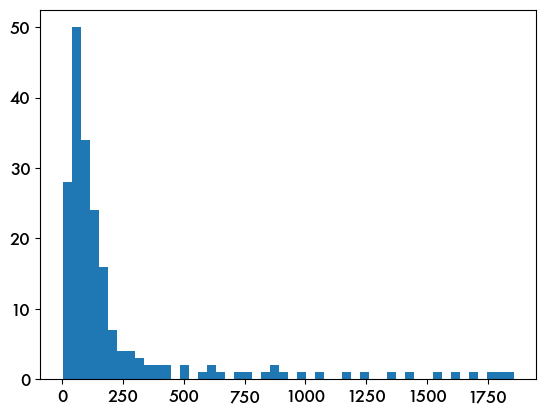

In [106]:
plt.hist(colocation['km_sep'], bins=50)

In [66]:
temp.loc[temp.km_sep.idxmin()].yd_sep%365

176.53630787037036

In [79]:
gsw.distance?

Signature: gsw.distance(lon, lat, p=0, axis=-1)
Docstring:
Great-circle distance in m between lon, lat points.

Parameters
----------
lon, lat : array-like, 1-D or 2-D (shapes must match)
    Longitude, latitude, in degrees.
p : array-like, scalar, 1-D or 2-D, optional, default is 0
    Sea pressure (absolute pressure minus 10.1325 dbar), dbar
axis : int, -1, 0, 1, optional
    The axis or dimension along which *lat and lon* vary.
    This differs from most functions, for which axis is the
    dimension along which p increases.

Returns
-------
distance : 1-D or 2-D array
    distance in meters between adjacent points.
File:      /opt/homebrew/Caskroom/mambaforge/base/envs/cremas/lib/python3.9/site-packages/gsw/geostrophy.py
Type:      function

In [ ]:
socat_DF 